<a href="https://colab.research.google.com/github/PurnaTejitha12/AI-Based-Early-Detection-of-Diabetic-Retinopathy/blob/main/Capstone_Project(EfficientNet_B0).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train_path = '/content/drive/MyDrive/dataset/train'
test_path = '/content/drive/MyDrive/dataset/test'

In [ ]:
import timm
import torch.nn as nn

def build_efficientnet_b0(num_classes=5, pretrained=True):
    backbone = timm.create_model('tf_efficientnet_b0_ns', pretrained=pretrained, num_classes=0)
    nf = backbone.num_features  # number of output features from the backbone

    # Classifier head
    head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(nf, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )

    class DRModel(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head = head

        def forward(self, x):
            x = self.backbone.forward_features(x)
            x = self.head(x)
            return x

    return DRModel(backbone, head)


In [ ]:
def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        preds = model(x)
        loss = criterion(preds, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (preds.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def eval_epoch(model, dataloader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            preds = model(x)
            loss = criterion(preds, y)
            total_loss += loss.item() * x.size(0)
            correct += (preds.argmax(1) == y).sum().item()
            total += x.size(0)
    return total_loss / total, correct / total


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Assuming you have defined train_path and test_path earlier
# Define transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Create datasets
train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_path, transform=test_transforms)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=32, shuffle=False) # Using test_dataset as validation

# Define criterion (loss function)
criterion = nn.CrossEntropyLoss()

Using device: cpu


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import timm

# Load model
def build_efficientnet_b0(num_classes=5, pretrained=True):
    backbone = timm.create_model('tf_efficientnet_b0_ns', pretrained=pretrained, num_classes=0)
    nf = backbone.num_features

    head = nn.Sequential(
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        nn.Dropout(0.3),
        nn.Linear(nf, 256),
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )

    class DRModel(nn.Module):
        def __init__(self, backbone, head):
            super().__init__()
            self.backbone = backbone
            self.head = head

        def forward(self, x):
            x = self.backbone.forward_features(x)
            x = self.head(x)
            return x

    return DRModel(backbone, head)

# Instantiate and load model
model = build_efficientnet_b0(num_classes=5).to(device)
model.eval()  # make sure model is in eval mode

# If you've saved a trained model:
# model.load_state_dict(torch.load("model_efficientnetb0.pth"))


# Helper: Unnormalize images for display
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean  # Unnormalize
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Class names (change if using custom labels)
class_names = train_dataset.classes  # or manually: ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative DR']

# Visualize predictions
def visualize_predictions(model, dataloader, num_images=6):
    model.eval()
    images_shown = 0
    plt.figure(figsize=(15, 8))

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, 1)

            for i in range(inputs.size(0)):
                if images_shown >= num_images:
                    break
                ax = plt.subplot(2, num_images//2, images_shown + 1)
                imshow(inputs[i])
                pred_label = class_names[preds[i]]
                true_label = class_names[labels[i]]
                title_color = "green" if pred_label == true_label else "red"
                ax.set_title(f"Pred: {pred_label}\nTrue: {true_label}", color=title_color)
                images_shown += 1

            if images_shown >= num_images:
                break

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.12/dist-packages/timm/models/_factory.py:138: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


In [ ]:
import torch.optim as optim
import torch

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10 # You can adjust this

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")

    # Training phase
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")

    # Validation phase
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.4f}")

    print("-" * 20)

print("Training finished.")

Epoch 1/10
Train Loss: 0.8530, Train Accuracy: 0.6320
Validation Loss: 1.3132, Validation Accuracy: 0.5081
--------------------
Epoch 2/10
Train Loss: 0.6162, Train Accuracy: 0.7596
Validation Loss: 0.7781, Validation Accuracy: 0.6633
--------------------
Epoch 3/10
Train Loss: 0.4869, Train Accuracy: 0.8136
Validation Loss: 0.4956, Validation Accuracy: 0.8004
--------------------
Epoch 4/10
Train Loss: 0.4833, Train Accuracy: 0.8076
Validation Loss: 0.5066, Validation Accuracy: 0.8024
--------------------
Epoch 5/10
Train Loss: 0.3410, Train Accuracy: 0.8812
Validation Loss: 0.3704, Validation Accuracy: 0.8427
--------------------
Epoch 6/10
Train Loss: 0.2529, Train Accuracy: 0.9076
Validation Loss: 0.4181, Validation Accuracy: 0.8629
--------------------
Epoch 7/10
Train Loss: 0.2582, Train Accuracy: 0.9052
Validation Loss: 0.1350, Validation Accuracy: 0.9597
--------------------
Epoch 8/10
Train Loss: 0.2048, Train Accuracy: 0.9340
Validation Loss: 0.0817, Validation Accuracy: 0.97

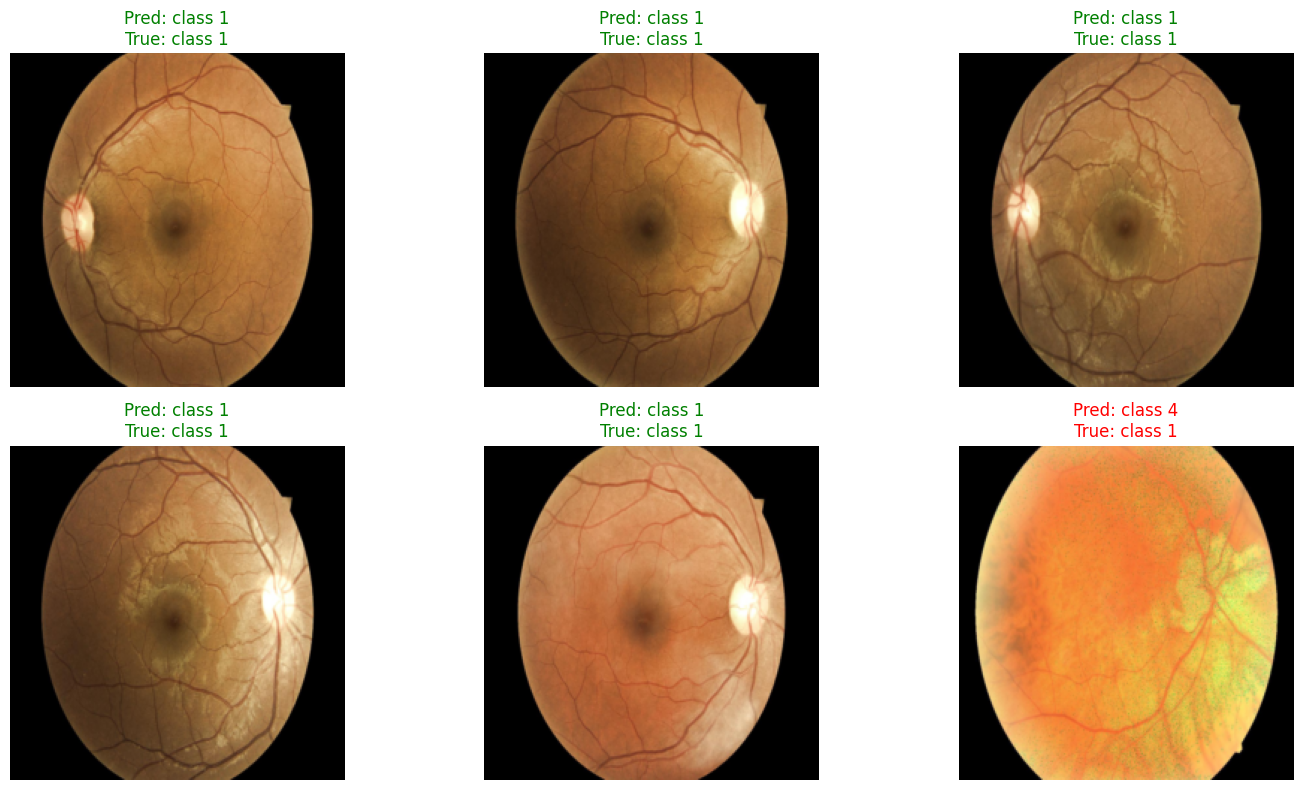

In [ ]:
visualize_predictions(model, val_loader, num_images=6)

In [ ]:
torch.save(model.state_dict(), "model_efficientnetb0.pth")

In [ ]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

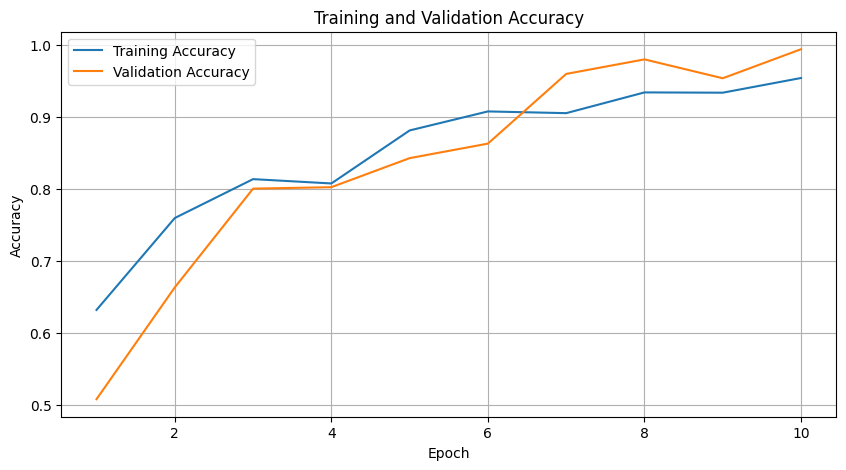

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_accuracies, label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


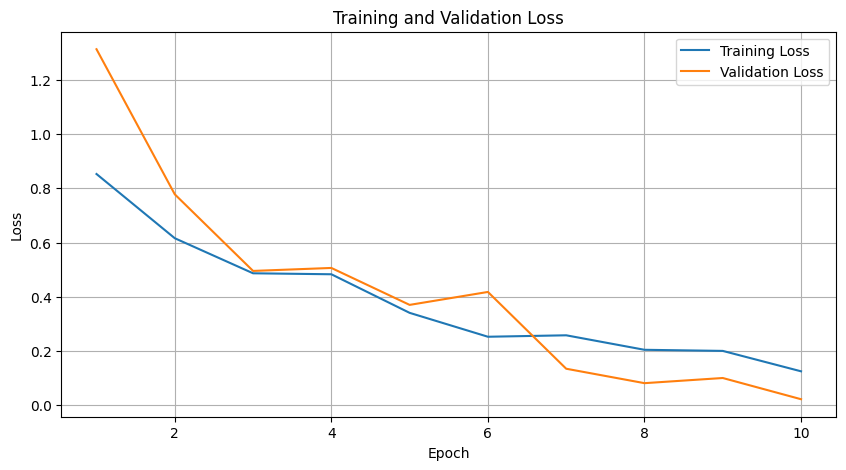

In [ ]:
# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.eval()
true_labels = []
predicted_labels = []

with torch.no_grad():
    for images, labels in val_loader:  # val_loader is your validation dataloader
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())



📊 Overall Macro F1-Score: 0.9939

🎯 Class-wise F1-Scores:
 - No DR: 1.0000
 - Mild: 1.0000
 - Moderate: 0.9950
 - Severe: 0.9895
 - Proliferative DR: 0.9852


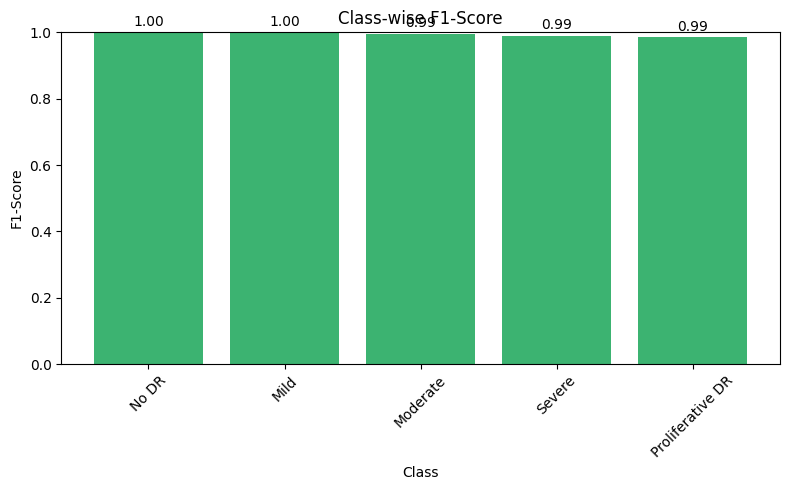

In [ ]:
from sklearn.metrics import f1_score
import numpy as np
import matplotlib.pyplot as plt

# Convert to numpy arrays if not already
true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# ✅ Safety check
if len(true_labels) == 0 or len(predicted_labels) == 0:
    raise ValueError("true_labels or predicted_labels are empty!")

# ✅ Overall (macro) F1-score
overall_f1 = f1_score(true_labels, predicted_labels, average='macro')
print(f"\n📊 Overall Macro F1-Score: {overall_f1:.4f}")

# ✅ Class-wise F1-score
class_f1_scores = f1_score(true_labels, predicted_labels, average=None)

# ✅ Print F1-scores for each class
print("\n🎯 Class-wise F1-Scores:")
for i, score in enumerate(class_f1_scores):
    print(f" - {class_names[i]}: {score:.4f}")

# ✅ Visualization
plt.figure(figsize=(8, 5))
plt.bar(class_names, class_f1_scores, color='mediumseagreen')
plt.title('Class-wise F1-Score')
plt.xlabel('Class')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)

# Annotate bars
for i, score in enumerate(class_f1_scores):
    plt.text(i, score + 0.02, f"{score:.2f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

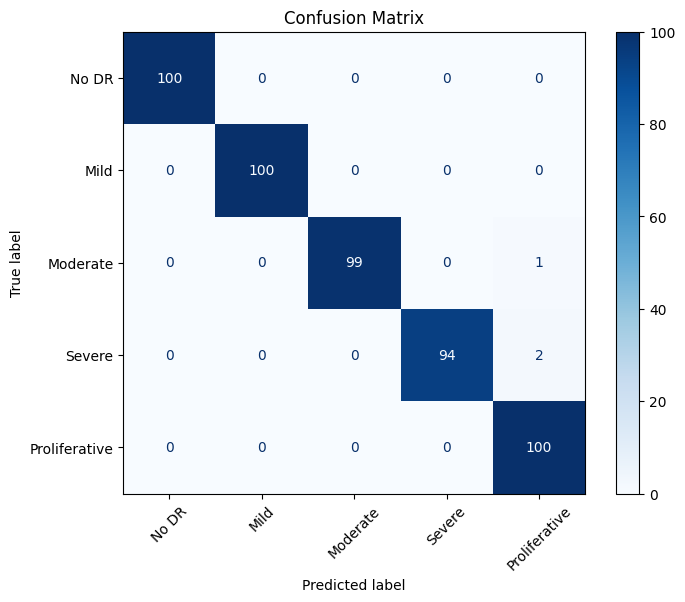

In [ ]:
# Define class names (edit according to your dataset)
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot using sklearn's display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.show()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [ ]:
model.eval()

true_labels = []
predicted_probs = []

with torch.no_grad():
    for images, labels in val_loader:  # replace with your DataLoader
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # get class probabilities

        true_labels.extend(labels.cpu().numpy())
        predicted_probs.extend(probs.cpu().numpy())

In [ ]:
# Assuming 5 classes
num_classes = 5
class_names = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

# Binarize the true labels (for multi-class ROC)
true_labels_bin = label_binarize(true_labels, classes=list(range(num_classes)))
predicted_probs = np.array(predicted_probs)

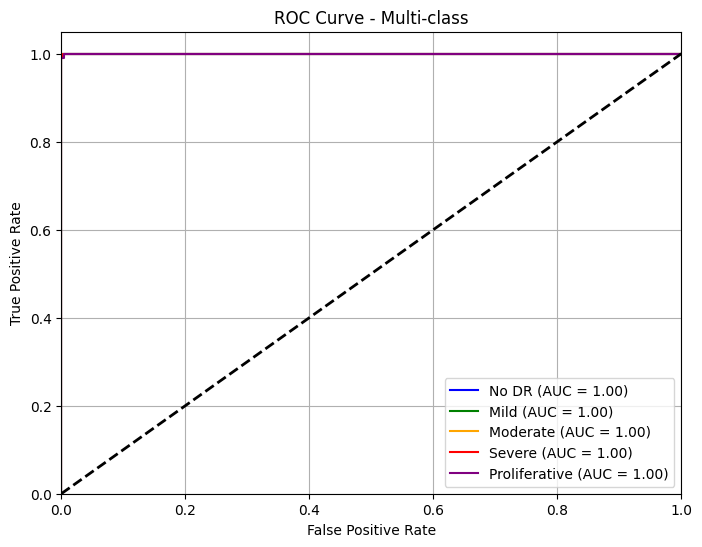

In [ ]:
# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(true_labels_bin[:, i], predicted_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'orange', 'red', 'purple']

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Multi-class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

# Macro AUC
macro_auc = roc_auc_score(true_labels_bin, predicted_probs, average='macro')
print("Macro AUC:", macro_auc)

# Micro AUC
micro_auc = roc_auc_score(true_labels_bin, predicted_probs, average='micro')
print("Micro AUC:", micro_auc)

Macro AUC: 0.9999846906565656
Micro AUC: 0.9999857732830385
